In [6]:
import pandas as pd
import joblib

In [7]:
df = pd.read_csv(
    "../data/processed/final_featured_sales.csv"
)

df = pd.get_dummies(
    df,
    columns=["Festival_Name"],
    drop_first=True
)

df.drop(
    columns=["Date"],
    inplace=True
)

TARGET = "Weekly_Sales"

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [8]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_test.shape)

(1287, 52)


In [9]:
xgb_model = joblib.load(
    "../models/best_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


Actual vs Predicted

In [10]:
xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:5])

[528382.94 527179.75 515860.6  510136.66 512802.5 ]


Prediction DataFrame

In [13]:
results_df = pd.DataFrame({

    "Actual": y_test,

    "Predicted": xgb_predictions

})

results_df.head()

,Actual,Predicted
5148,536006.73,528382.93750
5149,529852.70,527179.75000
5150,510382.50,515860.59375
5151,513615.82,510136.65625
5152,519255.68,512802.50000


Actual vs Predicted Plot

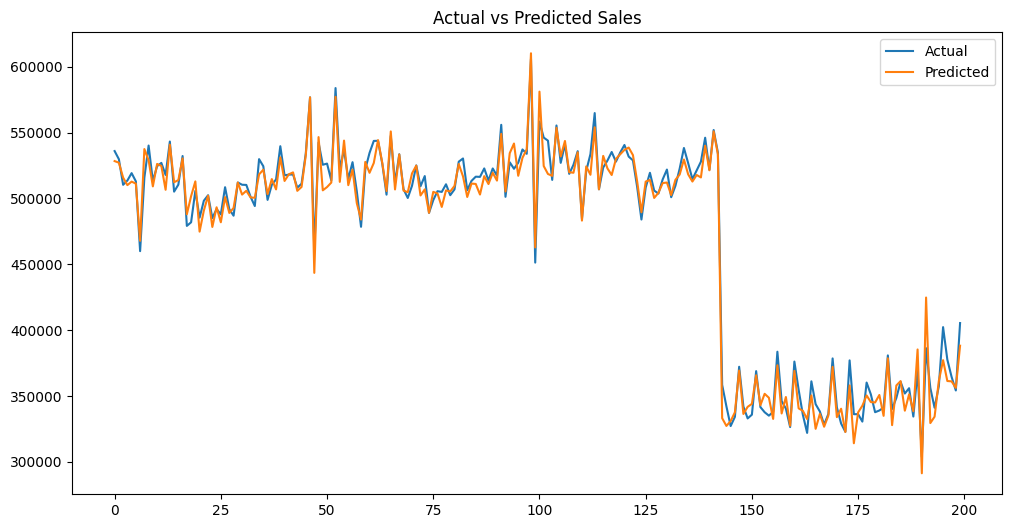

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    results_df["Actual"].values[:200],
    label="Actual"
)

plt.plot(
    results_df["Predicted"].values[:200],
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

Scatter Plot

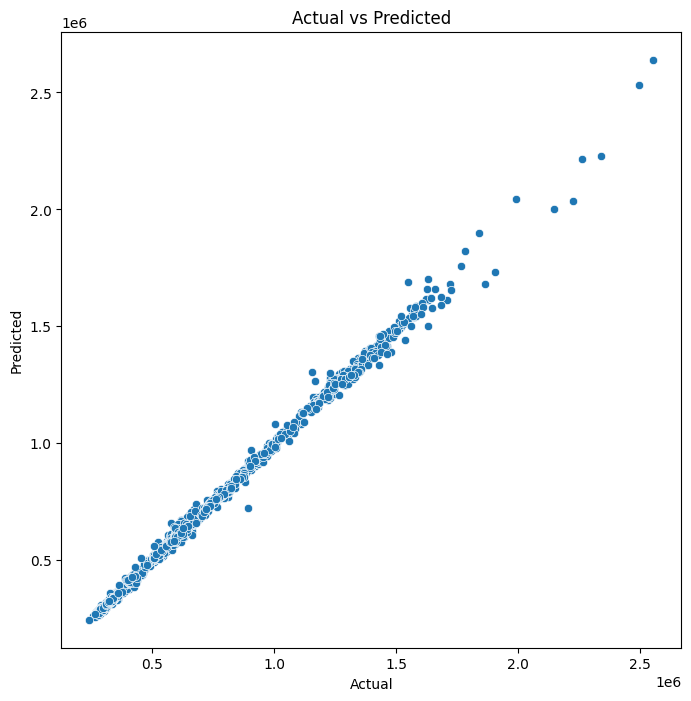

In [16]:
plt.figure(figsize=(8,8))

sns.scatterplot(

    x=results_df["Actual"],

    y=results_df["Predicted"]

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

Error Analysis

In [17]:
results_df["Error"] = (

    results_df["Actual"]

    -

    results_df["Predicted"]

)

results_df.head()

,Actual,Predicted,Error
5148,536006.73,528382.93750,7623.79250
5149,529852.70,527179.75000,2672.95000
5150,510382.50,515860.59375,-5478.09375
5151,513615.82,510136.65625,3479.16375
5152,519255.68,512802.50000,6453.18000


Error Distribution

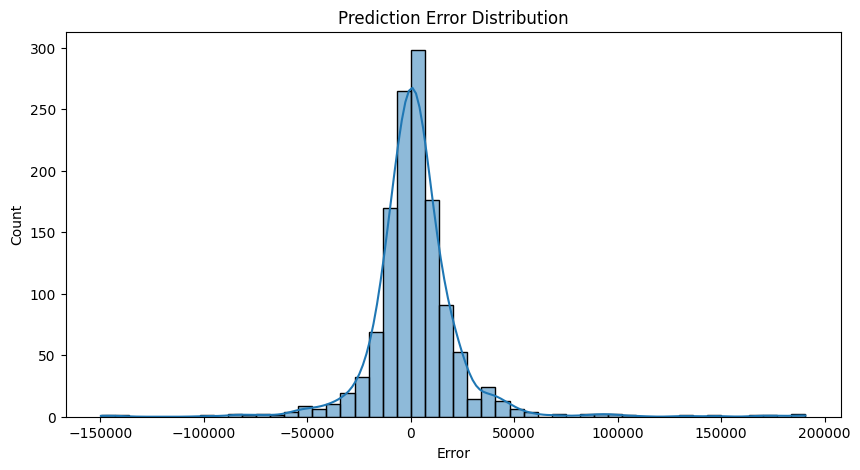

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(

    results_df["Error"],

    bins=50,

    kde=True

)

plt.title(
    "Prediction Error Distribution"
)

plt.show()

Residual Plot

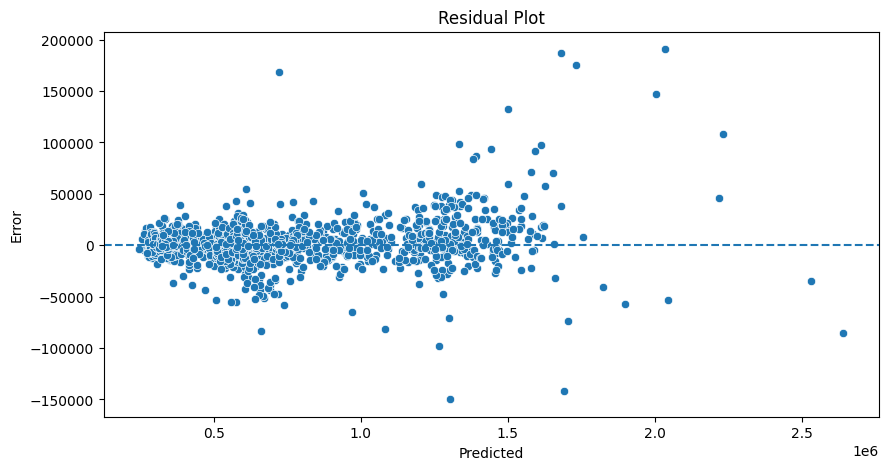

In [19]:
plt.figure(figsize=(10,5))

sns.scatterplot(

    x=results_df["Predicted"],

    y=results_df["Error"]

)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Residual Plot"
)

plt.show()

Performance Ranking

In [20]:
comparison = pd.read_csv(
    "../outputs/model_comparison.csv",
    index_col=0
)

comparison

,MAE,RMSE,MAPE,R2
Random Forest,13207.547954,24101.286108,1.780778,0.996162
XGBoost,13147.240033,22407.847358,1.768946,0.996683
LightGBM,13236.230122,23601.226442,1.798304,0.996320


Ranking Table

In [21]:
comparison["Rank"] = (

    comparison["R2"]

    .rank(
        ascending=False
    )

)

comparison.sort_values(
    "Rank"
)

,MAE,RMSE,MAPE,R2,Rank
XGBoost,13147.240033,22407.847358,1.768946,0.996683,1.0
LightGBM,13236.230122,23601.226442,1.798304,0.996320,2.0
Random Forest,13207.547954,24101.286108,1.780778,0.996162,3.0


Save Evaluation Results

In [22]:
results_df.to_csv(

    "../outputs/predictions.csv",

    index=False

)

print(
    "Evaluation results saved!"
)

Evaluation results saved!
